# Kriging — Gaussian Process Regression

**Kriging** (named after the South African geostatistician D. G. Krige) is a method for spatial interpolation under uncertainty. In the machine learning literature it is known as **Gaussian Process (GP) regression**. It provides not only a prediction but a full **posterior distribution**, encoding uncertainty via confidence bands.

## Gaussian Process Prior

A GP places a prior distribution over functions:

$$
f \sim \mathcal{GP}\bigl(0,\, k(\cdot,\cdot)\bigr),
$$

meaning that any finite collection $(f(x_1),\ldots,f(x_m))$ is jointly Gaussian with covariance
$\mathrm{Cov}(f(x_i), f(x_j)) = k(x_i, x_j).$
The kernel $k$ encodes smoothness assumptions about $f$.

## Squared-exponential (Gaussian) kernel

The most common kernel is the **squared-exponential**:

$$
k(x, y) = \exp\!\left(-\frac{(x-y)^2}{2\ell^2}\right),
$$

where $\ell > 0$ is the **length-scale** controlling how quickly the correlation decays with distance. Small $\ell$ allows rapid local variation; large $\ell$ enforces global smoothness.

## Posterior distribution

Given noisy observations $y_i = f(x_i) + \varepsilon_i$ with $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$, let $K$ denote the $n\times n$ kernel matrix $K_{ij} = k(x_i, x_j)$ and $\mathbf{k}(x) = (k(x_1, x), \ldots, k(x_n, x))^\top$. The posterior is:

$$
f(x) \mid \mathbf{y} \sim \mathcal{N}\!\bigl(\hat{f}(x),\; V(x)\bigr),
$$

with **posterior mean**

$$
\hat{f}(x) = \mathbf{k}(x)^\top (K + \sigma^2 I)^{-1} \mathbf{y},
$$

and **posterior variance**

$$
V(x) = k(x,x) - \mathbf{k}(x)^\top (K + \sigma^2 I)^{-1} \mathbf{k}(x).
$$

The **confidence band** $\hat{f}(x) \pm 2\sqrt{V(x)}$ covers the true function with approximately 95% probability under the GP prior.

This notebook:
- implements GP regression from scratch using Cholesky decomposition for numerical stability;
- sweeps over the length-scale $\ell$ and noise $\sigma^2$ to show their effect on the posterior;
- draws posterior samples to visualise the full distribution;
- provides an interactive widget for real-time exploration.

## Environment

In [1]:
import numpy as np
import matplotlib
if 'get_ipython' not in globals():
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.linalg import cho_factor, cho_solve
from ipywidgets import interact, FloatLogSlider

plt.rcParams['figure.dpi'] = 110
rng = np.random.default_rng(0)

## Core GP regression implementation

We build the kernel matrix and compute the posterior mean and variance via the **Cholesky decomposition** of $K + \sigma^2 I$. This is more numerically stable than direct matrix inversion and costs $O(n^3)$ time with $O(n^2)$ memory.

The kernel evaluations:
$$k(x, z) = \exp\!\left(-\frac{(x-z)^2}{2\ell^2}\right).$$

In [2]:
def rbf_kernel(x1, x2, ell):
    """Squared-exponential kernel matrix. x1: (m,), x2: (n,) -> (m, n)."""
    diff = x1[:, None] - x2[None, :]
    return np.exp(-0.5 * diff**2 / ell**2)

def gp_posterior(X_train, y_train, X_test, ell, sigma2):
    """Return posterior mean and standard deviation at X_test."""
    K    = rbf_kernel(X_train, X_train, ell) + sigma2 * np.eye(len(X_train))
    K_s  = rbf_kernel(X_train, X_test,  ell)   # (n, m)
    K_ss = rbf_kernel(X_test,  X_test,  ell)   # (m, m)

    cf   = cho_factor(K)
    alpha = cho_solve(cf, y_train)             # (K + σ²I)^{-1} y
    mu    = K_s.T @ alpha                       # posterior mean (m,)

    V_mat = K_ss - K_s.T @ cho_solve(cf, K_s)  # posterior covariance (m, m)
    std   = np.sqrt(np.maximum(np.diag(V_mat), 0.0))
    return mu, std, V_mat

## Data generation

We sample from a known ground-truth function $f_\star(x) = \sin(2x) + 0.4\cos(5x)$ and add Gaussian noise, giving us $n = 20$ training observations.

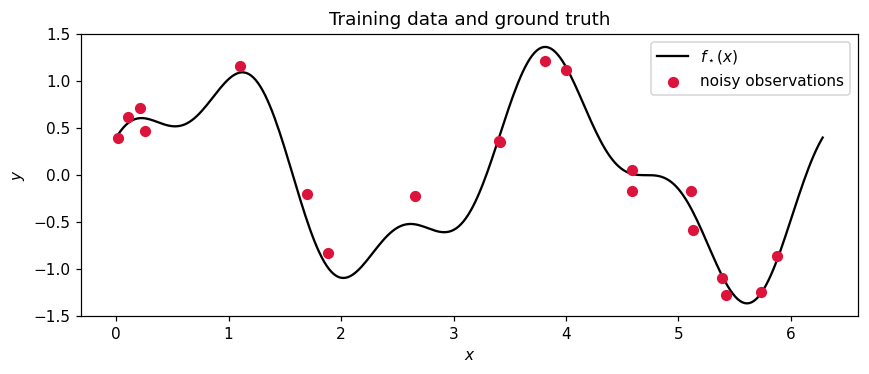

Saved gp_data.png


In [3]:
def f_true(x):
    return np.sin(2 * x) + 0.4 * np.cos(5 * x)

n_train  = 20
noise_sd = 0.2
X_train  = rng.uniform(0, 2 * np.pi, n_train)
y_train  = f_true(X_train) + rng.normal(0, noise_sd, n_train)
X_test   = np.linspace(0, 2 * np.pi, 300)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(X_test, f_true(X_test), 'k-', lw=1.5, label='$f_\\star(x)$')
ax.scatter(X_train, y_train, c='crimson', s=40, zorder=5, label='noisy observations')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('Training data and ground truth')
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig('gp_data.png', bbox_inches='tight')
plt.close()
print('Saved gp_data.png')

## Posterior with default parameters

We compute and plot the GP posterior mean and $\pm 2\sigma$ confidence band for a default choice of $\ell = 0.5$ and $\sigma^2 = 0.04$. The posterior mean should track the true function, and the confidence band should be narrow near training points and wide in unexplored regions.

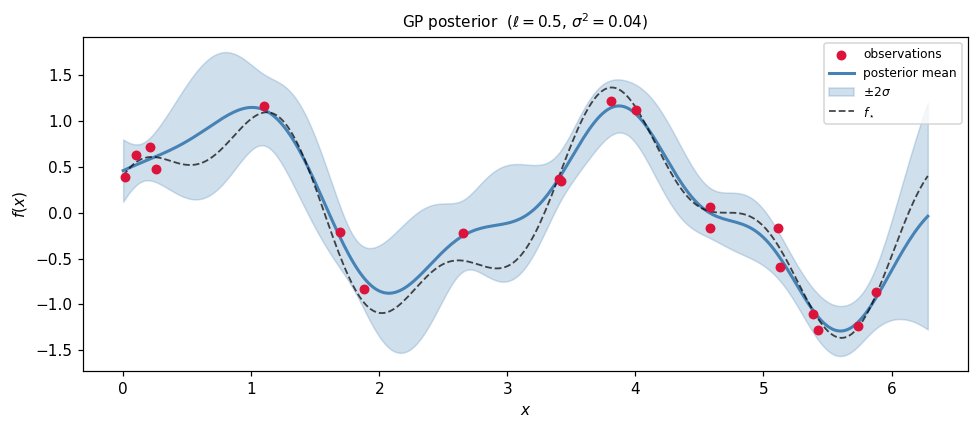

Saved gp_posterior.png


In [4]:
def plot_gp(ax, X_train, y_train, X_test, ell, sigma2, title='',
            show_truth=True, draw_samples=False, n_samples=5):
    mu, std, V_mat = gp_posterior(X_train, y_train, X_test, ell, sigma2)
    ax.scatter(X_train, y_train, c='crimson', s=30, zorder=5, label='observations')
    ax.plot(X_test, mu, 'steelblue', lw=2.0, label='posterior mean')
    ax.fill_between(X_test, mu - 2*std, mu + 2*std,
                    alpha=0.25, color='steelblue', label=r'$\pm 2\sigma$')
    if show_truth:
        ax.plot(X_test, f_true(X_test), 'k--', lw=1.2, alpha=0.7, label='$f_\\star$')
    if draw_samples:
        jitter = 1e-8 * np.eye(len(X_test))
        L = np.linalg.cholesky(V_mat + jitter)
        for _ in range(n_samples):
            s = mu + L @ rng.normal(0, 1, len(X_test))
            ax.plot(X_test, s, lw=0.8, alpha=0.45, color='darkorange')
    ax.set_xlabel('$x$'); ax.set_ylabel('$f(x)$')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')

fig, ax = plt.subplots(figsize=(9, 4))
plot_gp(ax, X_train, y_train, X_test, ell=0.5, sigma2=0.04,
        title='GP posterior  ($\\ell=0.5$, $\\sigma^2=0.04$)')
plt.tight_layout()
plt.show()
plt.savefig('gp_posterior.png', bbox_inches='tight')
plt.close()
print('Saved gp_posterior.png')

## Effect of length-scale $\ell$

The length-scale $\ell$ determines the **correlation length** of the GP:
- Small $\ell$: the function can vary rapidly; posterior quickly returns to the prior (zero mean) between observations.
- Large $\ell$: the function varies slowly; the posterior is oversmoothed and misses fine structure.

The panels below compare $\ell \in \{0.15, 0.5, 1.5, 4.0\}$ with fixed noise $\sigma^2 = 0.04$.

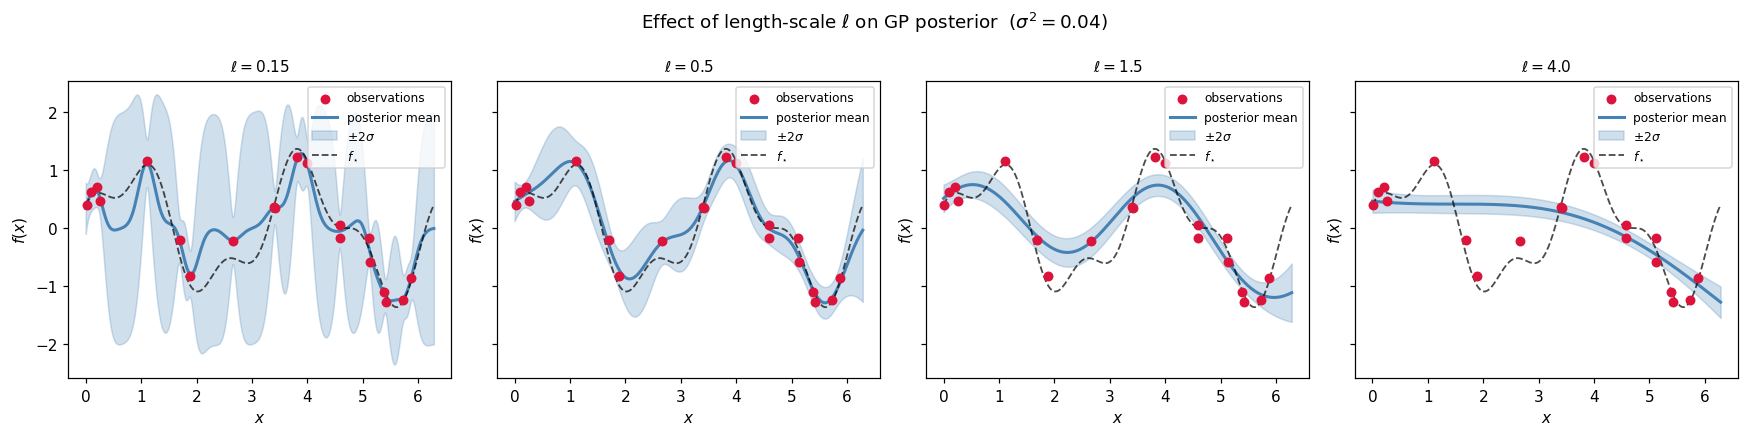

Saved ell_sweep.png


In [5]:
ell_vals = [0.15, 0.5, 1.5, 4.0]
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, ell in zip(axes, ell_vals):
    plot_gp(ax, X_train, y_train, X_test, ell=ell, sigma2=0.04,
            title=f'$\\ell = {ell}$', show_truth=True)
fig.suptitle('Effect of length-scale $\\ell$ on GP posterior  ($\\sigma^2=0.04$)', fontsize=12)
plt.tight_layout()
plt.show()
plt.savefig('ell_sweep.png', bbox_inches='tight')
plt.close()
print('Saved ell_sweep.png')

## Effect of noise $\sigma^2$

The noise variance $\sigma^2$ controls the trade-off between interpolation and smoothing:
- Small $\sigma^2$: near-exact interpolation of observations; posterior mean passes close to each data point.
- Large $\sigma^2$: the model attributes more variation to noise, producing a smoother posterior that averages over observations.

The panels compare $\sigma^2 \in \{0.001, 0.04, 0.2, 0.8\}$ with fixed $\ell = 0.5$.

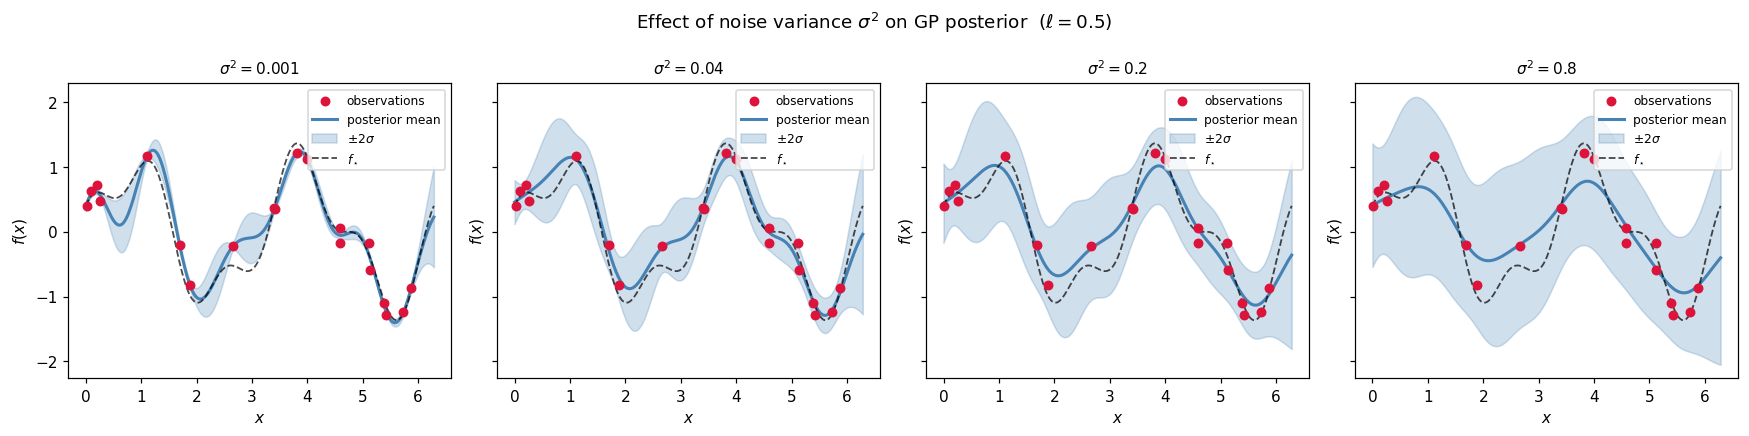

Saved sigma_sweep.png


In [6]:
sigma2_vals = [0.001, 0.04, 0.2, 0.8]
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, s2 in zip(axes, sigma2_vals):
    plot_gp(ax, X_train, y_train, X_test, ell=0.5, sigma2=s2,
            title=f'$\\sigma^2 = {s2}$')
fig.suptitle('Effect of noise variance $\\sigma^2$ on GP posterior  ($\\ell=0.5$)', fontsize=12)
plt.tight_layout()
plt.show()
plt.savefig('sigma_sweep.png', bbox_inches='tight')
plt.close()
print('Saved sigma_sweep.png')

## Posterior samples

The GP posterior is a full distribution over functions. We can draw **sample paths** from it by sampling from the multivariate Gaussian $\mathcal{N}(\hat{f}, V)$ at the test points. Each sample is a plausible realisation of the unknown function consistent with the observations.

The spread of samples visually confirms the confidence bands: near training points all samples cluster tightly, while in gaps they diverge widely.

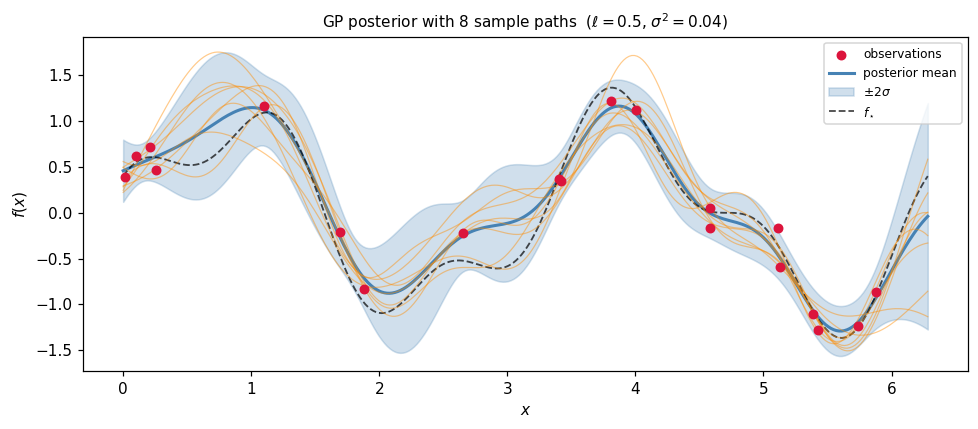

Saved gp_samples.png


In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_gp(ax, X_train, y_train, X_test, ell=0.5, sigma2=0.04,
        title='GP posterior with 8 sample paths  ($\\ell=0.5$, $\\sigma^2=0.04$)',
        draw_samples=True, n_samples=8)
plt.tight_layout()
plt.show()
plt.savefig('gp_samples.png', bbox_inches='tight')
plt.close()
print('Saved gp_samples.png')

## Posterior variance map

The **predictive variance** $V(x)$ quantifies epistemic uncertainty at each location. It is exactly zero at training points (noiseless case), and increases with distance from observed data up to the prior variance $k(x,x) = 1$. Visualising $V(x)$ directly reveals which regions are best informed by data.

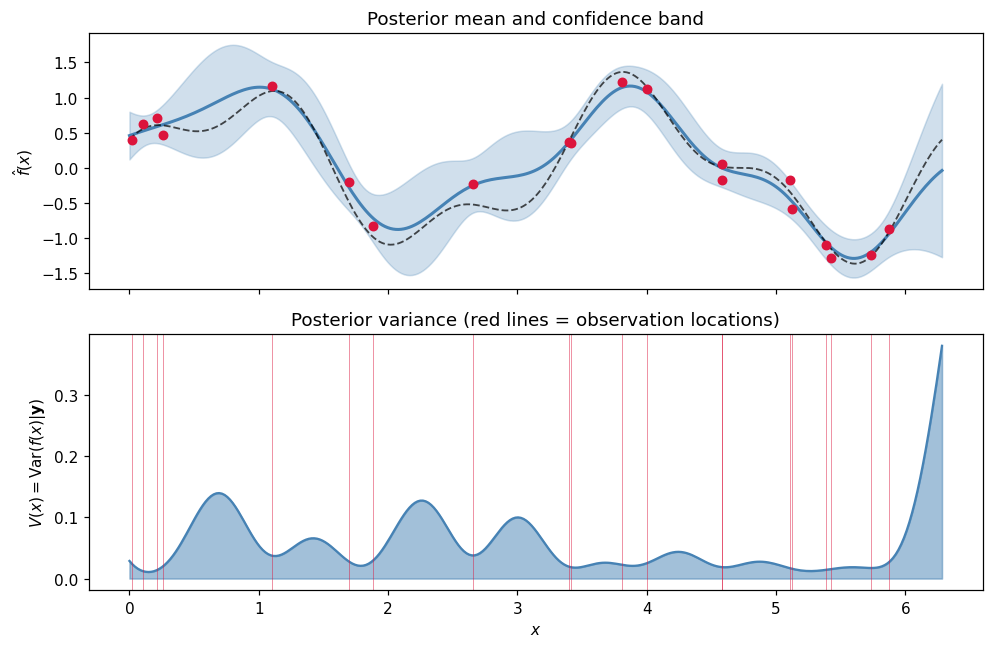

Saved gp_variance.png


In [8]:
ell_var, sigma2_var = 0.5, 0.04
mu_v, std_v, _ = gp_posterior(X_train, y_train, X_test, ell_var, sigma2_var)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(X_test, mu_v, 'steelblue', lw=2, label='posterior mean')
axes[0].fill_between(X_test, mu_v-2*std_v, mu_v+2*std_v,
                      alpha=0.25, color='steelblue')
axes[0].scatter(X_train, y_train, c='crimson', s=30, zorder=5)
axes[0].plot(X_test, f_true(X_test), 'k--', lw=1.2, alpha=0.7)
axes[0].set_ylabel('$\\hat{f}(x)$')
axes[0].set_title('Posterior mean and confidence band')

axes[1].fill_between(X_test, 0, std_v**2, color='steelblue', alpha=0.5)
axes[1].plot(X_test, std_v**2, 'steelblue', lw=1.5)
for xi in X_train:
    axes[1].axvline(xi, color='crimson', lw=0.6, alpha=0.5)
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$V(x) = \\mathrm{Var}(f(x)|\\mathbf{y})$')
axes[1].set_title('Posterior variance (red lines = observation locations)')

plt.tight_layout()
plt.show()
plt.savefig('gp_variance.png', bbox_inches='tight')
plt.close()
print('Saved gp_variance.png')

## Interactive GP explorer

The sliders let you tune $\ell$ and $\sigma^2$ and observe the immediate effect on the posterior mean, confidence band, and sample paths.

## Static snapshot

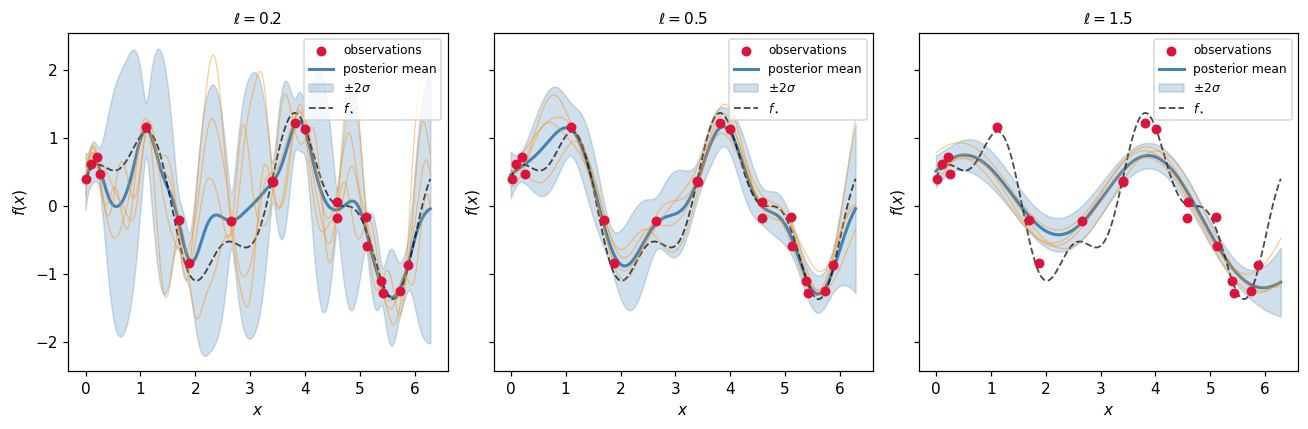

Saved snippet.png


In [9]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    ell_vals_snap = [0.2, 0.5, 1.5]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
    for ax, ell in zip(axes, ell_vals_snap):
        plot_gp(ax, X_train, y_train, X_test, ell=ell, sigma2=0.04,
                title=f'$\\ell = {ell}$', draw_samples=True, n_samples=4)
    plt.tight_layout()
    plt.show()
    plt.savefig('snippet.png', bbox_inches='tight')
    plt.close()
    print('Saved snippet.png')

## Takeaways

- Kriging / GP regression delivers a **Bayesian posterior**: a mean prediction together with calibrated uncertainty bands, not just a point estimate.
- The **length-scale** $\ell$ controls functional smoothness; it should be tuned (e.g. via marginal likelihood maximisation) to match the true signal.
- The **noise variance** $\sigma^2$ controls interpolation vs. smoothing; small $\sigma^2$ fits the data closely, large $\sigma^2$ is more robust to outliers.
- Posterior **samples** reveal the full distribution over plausible functions and are especially useful for downstream Bayesian optimisation.
- The $O(n^3)$ cost of Cholesky factorisation limits exact GP inference to $n \lesssim 10^4$; sparse and inducing-point approximations extend it to larger datasets.

## Bibliography

- Krige, D. G. (1951). A statistical approach to some basic mine valuation problems on the Witwatersrand. *J. Chem. Metall. Min. Soc. South Africa*, 52(6), 119–139.
- Rasmussen, C. E. and Williams, C. K. I. (2006). *Gaussian Processes for Machine Learning*. MIT Press.
- Matheron, G. (1963). Principles of geostatistics. *Economic Geology*, 58(8), 1246–1266.
- Stein, M. L. (1999). *Interpolation of Spatial Data: Some Theory for Kriging*. Springer.
- Snoek, J., Larochelle, H., and Adams, R. P. (2012). Practical Bayesian optimization of machine learning algorithms. *NeurIPS 2012*.